In [1]:
import os
import sys
import wandb
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'scripts'))

In [2]:
from model import GraphSAGENet
from process_data import DataProcessor
from train import train_epoch_full_graph, evaluate_full_graph

In [3]:
run = wandb.init(
    entity="abdelrahman-helal-minerva-university",
    project="graphsage-ckdtree",
    config={
        "model": "GraphSAGE",
        "num_layers": 2,
        "hidden_channels": 64,
        "mlp_hidden": 128,
        "learning_rate": 0.01,
        "num_epochs": 100,
        "device": "cpu" if not torch.cuda.is_available() else "cuda"
    },
    mode="online"  # Use online mode to avoid local file issues
)

wandb: Currently logged in as: abdelrahman-helal (abdelrahman-helal-minerva-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [4]:
data_path = 'D:\Minerva/Senior Year/Capstone/DM_FIREbox_fresh/data/firebox_data/FIREbox_z=0.txt'
data_processor = DataProcessor(file_path=data_path)

<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Abdelrahman Helal\AppData\Local\Temp\ipykernel_5248\2818861111.py:1: SyntaxWarning: invalid escape sequence '\M'
  data_path = 'D:\Minerva/Senior Year/Capstone/DM_FIREbox_fresh/data/firebox_data/FIREbox_z=0.txt'


In [6]:
from sklearn.preprocessing import StandardScaler
df = data_processor.df_filtered[data_processor.df_filtered['lg_Mstar_<Rhalo'] > 0]
scaler = StandardScaler()
cols = ['Rhalo', 'pos_x', 'pos_y', 'pos_z', \
        'vel_x', 'vel_y', 'vel_z', 'lg_Mstar_<Rhalo']
X = df[cols].values
y = df['lg_Mhalo'].values
X_scaled = scaler.fit_transform(X)


In [14]:
np.mean(X_scaled[:, 3])

np.float64(8.92038200374824e-17)

In [15]:
num_layers = 2
hidden_channels = 64
mlp_hidden = 128
learning_rate = 0.01
num_epochs = 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [18]:
# df = data_processor.df_filtered
# min_radius = np.sqrt(min(df['pos_x']**2 + df['pos_y']**2 + df['pos_z']**2))
# max_radius = np.sqrt(max(df['pos_x']**2 + df['pos_y']**2 + df['pos_z']**2)) 

r_values = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
all_r_predictions = []
all_r_residuals = []
train_losses = []
val_rmses = []
val_maes = []

for r in r_values:
    data_processor.create_graph_data(r=r, include_lg_Mstar=True, stratify_bins=10)
    data = data_processor.data
    model = GraphSAGENet(
        in_channels=data.x.size(1),
        hidden_channels=hidden_channels,
        num_layers=num_layers,
        mlp_hidden=mlp_hidden
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    best_val_rmse = float('inf')
    train_loss = []
    val_rmse = []
    val_mae = []
    
    for epoch in range(num_epochs):
        train_loss.append(train_epoch_full_graph(model, optimizer, data, device))
        val_rmse.append(evaluate_full_graph(model, data, device)[0])
        val_mae.append(evaluate_full_graph(model, data, device)[1])
    
    train_losses.append(train_loss[-1])
    val_rmses.append(val_rmse[-1])
    val_maes.append(val_mae[-1])
    predictions = model.predict(data, device)
    residuals = predictions - data.y.view(-1).cpu()
    all_r_predictions.append(predictions)
    all_r_residuals.append(residuals)

    if val_rmse[-1] < best_val_rmse:
        best_val_rmse = val_rmse[-1]
    
    print(f'Best validation RMSE for r={r}: {best_val_rmse:.4f}')

Best validation RMSE for r=0.2: 0.2628
Best validation RMSE for r=0.4: 0.2693
Best validation RMSE for r=0.6: 0.2477
Best validation RMSE for r=0.8: 0.2649
Best validation RMSE for r=1.0: 0.2343
Best validation RMSE for r=1.2: 0.2137
Best validation RMSE for r=1.4: 0.2438


RuntimeError: bad allocation

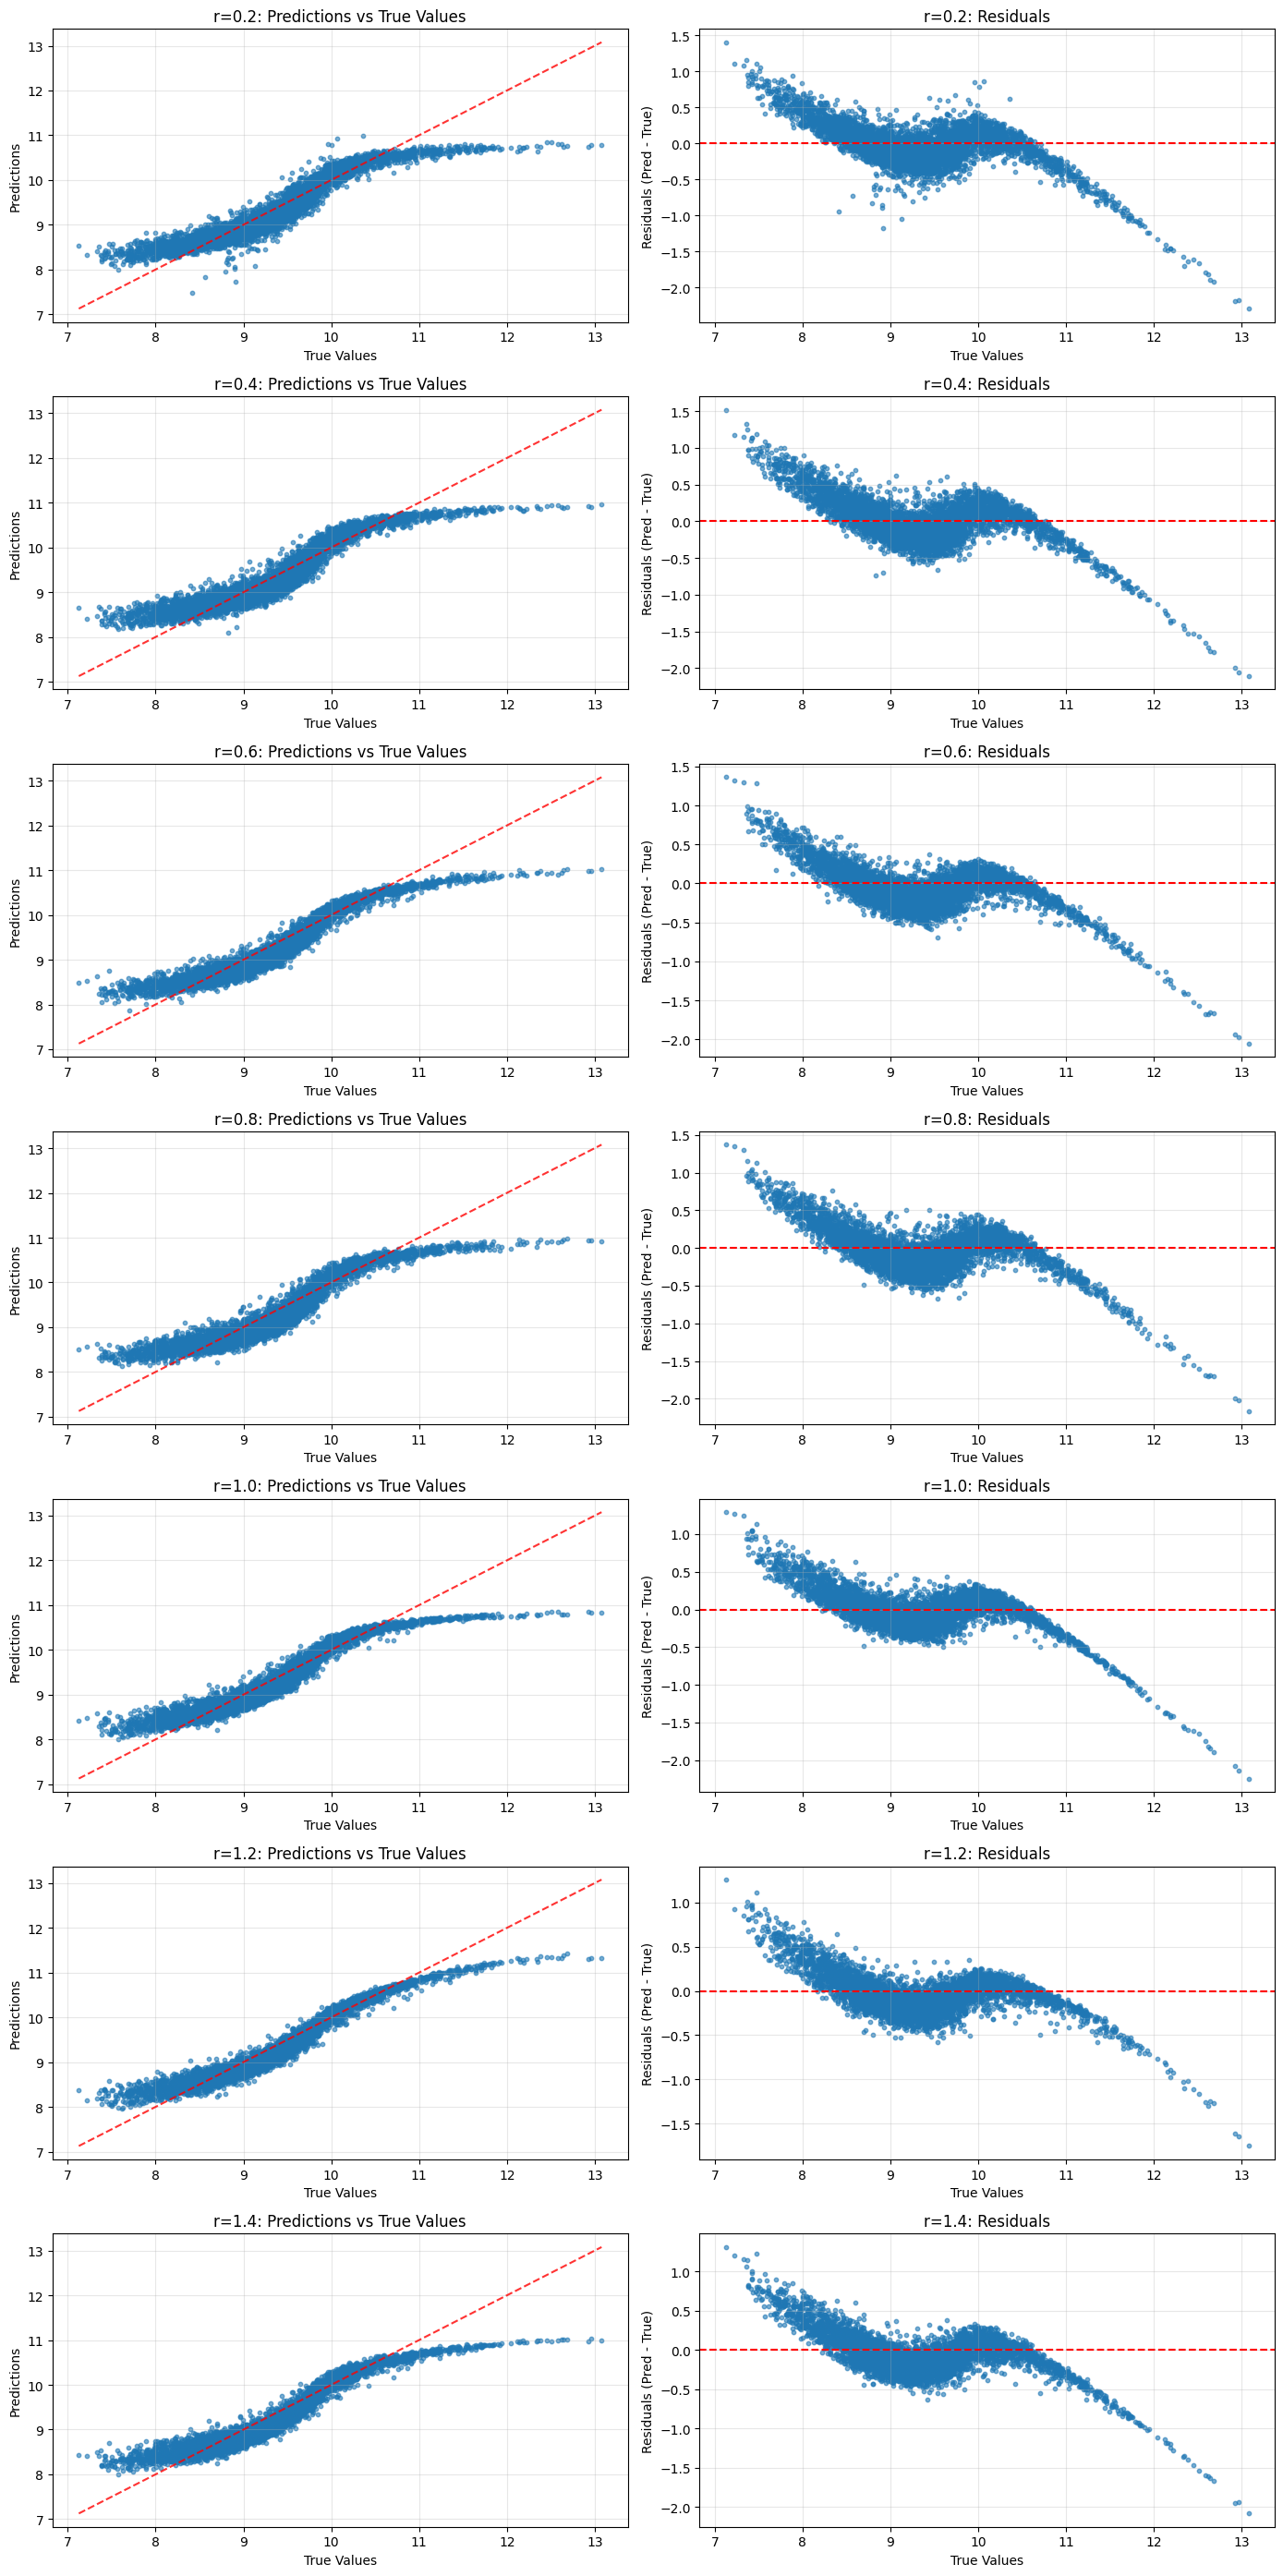

In [21]:
import matplotlib.pyplot as plt
import numpy as np

all_true_values = data.y.view(-1).cpu()
# Create visualization for each k value
fig, axes = plt.subplots(7, 2, figsize=(14, 28))


for i, r in enumerate(r_values[:-1]):
    # Get predictions and residuals for this k value
    predictions = all_r_predictions[i]  # Adjust indexing based on your data structure
    residuals = all_r_residuals[i]
    true_values = all_true_values
    
    # True vs Predictions plot
    axes[i, 0].scatter(true_values, predictions, alpha=0.6, s=10)
    axes[i, 0].set_xlabel('True Values')
    axes[i, 0].set_ylabel('Predictions')
    axes[i, 0].set_title(f'r={r}: Predictions vs True Values')
    axes[i, 0].grid(True, alpha=0.3)
    
    # Add perfect prediction line
    min_val = min(true_values.min(), predictions.min())
    max_val = max(true_values.max(), predictions.max())
    axes[i, 0].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
    
    # Residuals plot
    axes[i, 1].scatter(true_values, residuals, alpha=0.6, s=10)
    axes[i, 1].axhline(y=0, color='r', linestyle='--')
    axes[i, 1].set_xlabel('True Values')
    axes[i, 1].set_ylabel('Residuals (Pred - True)')
    axes[i, 1].set_title(f'r={r}: Residuals')
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
